# Kwant — Theory and Practice · Chapter 1
## Foundations — from the Schrödinger equation to a first conductance

*Part I · Sections 1–4 · Figures 1–6* &nbsp;·&nbsp; [Contents](00_Contents.ipynb) · [Chapter 2 →](02_Shapes_Spin_and_Bands.ipynb)

### In this chapter

- [1. Theory — From the Schrödinger equation to a tight-binding lattice](#1.-Theory-—-From-the-Schrödinger-equation-to-a-tight-binding-lattice)
    - [Reading the result](#Reading-the-result)
- [2. The object model](#2.-The-object-model)
    - [The vocabulary](#The-vocabulary)
    - [The two indexing rules](#The-two-indexing-rules)
    - [`norbs` matters](#norbs-matters)
    - [Finalisation](#Finalisation)
- [3. First transport calculation — a quantum wire](#3.-First-transport-calculation-—-a-quantum-wire)
    - [What you should see](#What-you-should-see)
- [4. Theory — Scattering theory: Landauer–Büttiker and Fisher–Lee](#4.-Theory-—-Scattering-theory:-Landauer–Büttiker-and-Fisher–Lee)
    - [The Landauer picture](#The-Landauer-picture)
    - [Fisher–Lee: from Green's functions to $S$](#Fisher–Lee:-from-Green's-functions-to-$S$)
    - [What Kwant actually solves](#What-Kwant-actually-solves)

Run the **Setup** cell first: it imports Kwant, reports the sparse solver, mutes three library warnings and defines `show_fig`, whose figure counter continues the course-wide numbering. Each chapter is self-contained given its Setup cell (a *carried over* cell, where present, rebuilds an object defined in an earlier chapter). Installation, the `kwant` kernel and the conventions are in [`00_Contents.ipynb`](00_Contents.ipynb).

`SPDX-License-Identifier: Apache-2.0` — Copyright 2026 Fabio Campolim.


In [1]:
# --- Setup: run this cell first ----------------------------------------------
# Imports, the sparse-solver report, three muted library warnings, and the
# figure helper.  Every chapter of the course starts with this cell.
import kwant
import numpy as np
import scipy
import tinyarray as ta                   # noqa: F401  (used by later cells)
import matplotlib
from matplotlib import pyplot

print("kwant", kwant.__version__, "| numpy", np.__version__,
      "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__)

# Which sparse solver is active? MUMPS is much faster than SciPy's SuperLU.
import kwant.solvers.default
print("default solver:", kwant.solvers.default.__name__)
try:
    import kwant.solvers.mumps          # noqa: F401
    print("MUMPS available: yes")
except ImportError:
    print("MUMPS available: no  (falling back to scipy sparse -> slower)")

matplotlib.rcParams['figure.figsize'] = (7, 5)

# Mute three library warnings that are not ours to fix and would otherwise be
# printed under some figures.  Done by wrapping warnings.showwarning rather than
# with warnings.filterwarnings(), because kwant.plotter calls
# warnings.resetwarnings() on every 3D plot, which silently deletes all user
# filters (reported upstream).  Only these three messages are muted:
#  * kwant 1.5.0's 3D plotter calls a matplotlib function deprecated in 3.10
#    (fixed on Kwant's main branch, unreleased);
#  * mpmath (via sympy) uses a deprecated bitcount helper;
#  * kwant.plotter.map notes that a few density values exceed the colour range,
#    which is expected for the delta-like densities in sections 6 and 12.
import warnings
_MUTED = ('proj_transform_clip', 'bitcount function is deprecated', 'overflowing upper limit')
_showwarning = warnings.showwarning

def _quiet_showwarning(message, category, filename, lineno, file=None, line=None):
    if not any(k in str(message) for k in _MUTED):
        _showwarning(message, category, filename, lineno, file, line)

warnings.showwarning = _quiet_showwarning

# --- Figure helper ------------------------------------------------------------
# Every figure ends with show_fig("..."), which stamps an auto-numbered italic
# caption under the figure and then shows it.  Figures are numbered
# continuously across the chapters of the course: this chapter's figures are
# 1–6, so the counter starts at 0.  (Re-running a single cell out of
# order advances it -- harmless, but numbers shift.)
_FIG_NO = [0]

def show_fig(caption=None):
    if caption:
        _FIG_NO[0] += 1
        fig = pyplot.gcf()
        fig.text(0.5, -0.02, f"Figure {_FIG_NO[0]}: {caption}",
                 ha='center', va='top', fontsize=9, style='italic',
                 wrap=True, transform=fig.transFigure)
    pyplot.show()


kwant 1.5.0 | numpy 2.5.1 | scipy 1.18.0 | matplotlib 3.10.7
default solver: kwant.solvers.default
MUMPS available: yes


---
## 1. Theory — From the Schrödinger equation to a tight-binding lattice

Kwant solves **tight-binding** models. Most continuum problems become tight-binding models
by discretisation, so this is the natural starting point.

Take the 2D single-particle Schrödinger Hamiltonian with a confining potential:

$$H = \frac{-\hbar^2}{2m}\left(\partial_x^2 + \partial_y^2\right) + V(x,y)$$

Put it on a square grid of spacing $a$, so that lattice indices $(i,j)$ map to real space
as $(x,y) = (ai, aj)$. Writing $\lvert i,j\rangle \equiv \lvert ai, aj\rangle$, the
second derivative becomes the standard three-point stencil

$$\partial_x^2 \;\to\; \frac{1}{a^2}\sum_{i,j}\Big(
\lvert i{+}1,j\rangle\langle i,j\rvert
+ \lvert i,j\rangle\langle i{+}1,j\rvert
- 2\lvert i,j\rangle\langle i,j\rvert \Big)$$

and likewise for $\partial_y^2$. Substituting gives

$$H = \sum_{i,j}\Big[\big(V(ai,aj) + 4t\big)\lvert i,j\rangle\langle i,j\rvert
- t\big(\lvert i{+}1,j\rangle\langle i,j\rvert + \mathrm{h.c.}
+ \lvert i,j{+}1\rangle\langle i,j\rvert + \mathrm{h.c.}\big)\Big]$$

with the **hopping integral**

$$t = \frac{\hbar^2}{2ma^2}.$$

### Reading the result

Two structural facts do all the work in Kwant:

1. **On-site energy** $= V + 4t$ in 2D (in $d$ dimensions, $V + 2dt$). The $2dt$ offset is
   the diagonal part of the stencil; it shifts the band bottom to $E=0$.
2. **Hopping** $= -t$ between nearest neighbours. Everything else is zero.

The dispersion of the infinite clean lattice is
$$E(\mathbf{k}) = 4t - 2t\cos(k_x a) - 2t\cos(k_y a) \;\xrightarrow{\;ka\ll 1\;}\; t a^2 k^2 = \frac{\hbar^2k^2}{2m},$$
which recovers the continuum parabola. **This is the accuracy criterion**: the discretisation
is faithful for states whose wavelength is much longer than $a$, i.e. only near the band
bottom. Push to high energy and you are simulating a lattice, not the continuum.

**Hard walls are free**: simply do not create sites beyond the boundary. This is why Kwant
systems are defined by *shape functions* rather than by boundary conditions.

Kwant is agnostic about where the model came from — you can equally hand it a genuine
atomistic tight-binding model (graphene, § 8) or a $k\cdot p$ model discretised
symbolically (§ 13).

**How good is the discretisation?**  Finite differences replace $-\partial_x^2$
by a hopping matrix whose dispersion is $\frac{2}{a^2}(1-\cos ka) = k^2 -
\frac{a^2k^4}{12}+\dots$ — the lattice is a faithful continuum only for
$ka \ll 1$, i.e. for energies well below the band edge $4t$ per direction.
Everything downstream (band structures, conductances, invariants) silently
carries this $\mathcal{O}(a^2k^4)$ error, which is why several later sections
end with an explicit lattice-vs-continuum comparison.  *Further reading:*
LeVeque, *Finite Difference Methods for ODEs and PDEs* (SIAM, 2007);
the Kwant paper, Groth *et al.*, New J. Phys. **16**, 063065 (2014).


---
## 2. The object model

Kwant separates **construction** from **computation**.

```
Builder  ──.finalized()──▶  FiniteSystem / InfiniteSystem  ──▶  solvers
(mutable, dict-like)         (immutable, array-based)
```

### The vocabulary

| Concept | What it is |
|---|---|
| **Site** | A degree of freedom's location. A `Site` = a `SiteFamily` + an integer `tag`. |
| **SiteFamily** | A class of sites, e.g. one sublattice of a lattice. Carries `norbs`. |
| **Monatomic** | A Bravais lattice: one site per unit cell. `lat(i, j)` → `Site`. |
| **Polyatomic** | A lattice with several sublattices, e.g. honeycomb. Has `.sublattices`. |
| **Builder** | A dict-like container mapping sites → on-site values and pairs → hoppings. |
| **HoppingKind** | A *pattern*: "all hoppings displaced by this lattice vector, from family A to family B". |
| **TranslationalSymmetry** | Makes a `Builder` infinite and periodic — this is what a lead is. |
| **Lead** | A semi-infinite, translationally invariant `Builder` attached to the system. |

### The two indexing rules

```python
syst[site]              = value   # on-site  ⟨site|H|site⟩
syst[site_a, site_b]    = value   # hopping  ⟨site_a|H|site_b⟩
```

Kwant **automatically adds the Hermitian conjugate**, so you specify each hopping once.
Values may be numbers, matrices, *or functions* — functions are evaluated lazily at solve
time and receive the site(s) plus user parameters (§ 5).

Bulk assignment works with generators, lists and `HoppingKind`s:

```python
syst[(lat(x, y) for x in range(L) for y in range(W))] = 4 * t   # generator, not tuple!
syst[lat.neighbors()]                                  = -t     # all nearest neighbours
syst[kwant.builder.HoppingKind((1, 0), lat)]           = -t     # one specific direction
```

> **Trap.** `syst[a, b]` is Python for `syst[(a, b)]`, so a *tuple* of two sites always
> means a hopping. That is why you cannot add several sites as a tuple — use a generator or
> a list. `del syst[...]` removes sites/hoppings with the same patterns.

### `norbs` matters

`norbs` declares how many orbitals live on each site (1 for spinless, 2 for spin or for
electron–hole, 4 for BHZ). Kwant needs it for `kwant.operator` and for symmetry checking,
and warns if it is missing. **Always set it.**

### Finalisation

`.finalized()` freezes the graph, orders the sites, and builds the sparse matrix machinery.
The `Builder` can then be garbage-collected, which matters for large systems. Finalised
systems are what solvers accept; they cannot be modified.

In [2]:
# --- The object model, concretely -------------------------------------------
import kwant

lat = kwant.lattice.square(a=1, norbs=1)     # a Monatomic site family

site = lat(2, 3)
print("site       :", site)
print("  family   :", site.family)
print("  tag      :", site.tag)              # integer lattice coordinates
print("  pos      :", site.pos)              # real-space position

syst = kwant.Builder()
syst[lat(0, 0)] = 4.0
syst[lat(1, 0)] = 4.0
syst[lat(0, 0), lat(1, 0)] = -1.0            # h.c. added automatically

print("\nnumber of sites   :", len(list(syst.sites())))
print("value at (0,0)    :", syst[lat(0, 0)])
print("hopping (0,0)-(1,0):", syst[lat(0, 0), lat(1, 0)])
print("reversed hopping   :", syst[lat(1, 0), lat(0, 0)])   # conjugate, free of charge

site       : <Site [2 3] of <unnamed Monatomic lattice, vectors [1.0 0.0], [0.0 1.0], origin [0.0 0.0], with 1 orbitals>>
  family   : <unnamed Monatomic lattice, vectors [1.0 0.0], [0.0 1.0], origin [0.0 0.0], with 1 orbitals>
  tag      : [2 3]
  pos      : [2.0 3.0]

number of sites   : 2
value at (0,0)    : 4.0
hopping (0,0)-(1,0): -1.0
reversed hopping   : -1.0


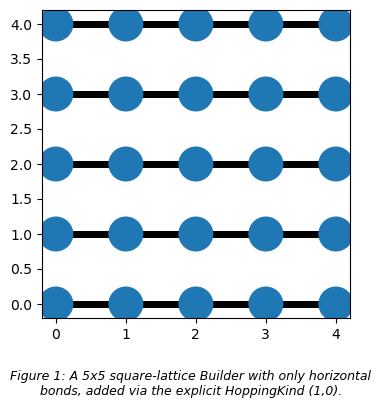

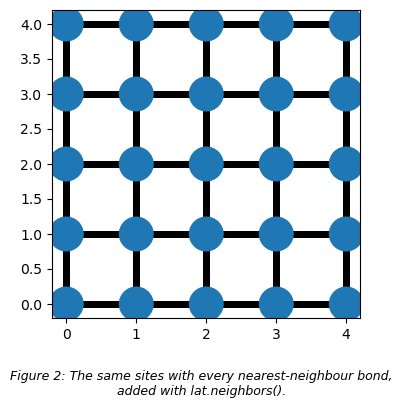

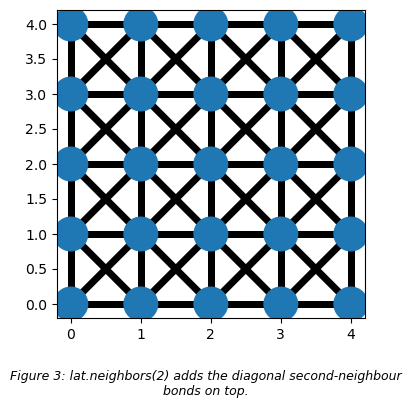

In [3]:
# --- HoppingKind vs lat.neighbors() -----------------------------------------
import kwant
from matplotlib import pyplot

lat = kwant.lattice.square(norbs=1)

syst = kwant.Builder()
syst[(lat(i, j) for i in range(5) for j in range(5))] = 4

# (a) only horizontal bonds, via an explicit HoppingKind pattern
syst[kwant.builder.HoppingKind((1, 0), lat)] = -1
kwant.plot(syst, fig_size=(4, 4), show=False)
show_fig(r'A 5x5 square-lattice Builder with only horizontal bonds, added via the explicit HoppingKind (1,0).')

# (b) wipe them and use all nearest neighbours instead
del syst[kwant.builder.HoppingKind((1, 0), lat)]
syst[lat.neighbors()] = -1          # == lat.neighbors(1)
kwant.plot(syst, fig_size=(4, 4), show=False)
show_fig(r'The same sites with every nearest-neighbour bond, added with lat.neighbors().')

# (c) second-nearest neighbours too
syst[lat.neighbors(2)] = -0.2
kwant.plot(syst, fig_size=(4, 4), show=False)
show_fig(r'lat.neighbors(2) adds the diagonal second-neighbour bonds on top.')

---
## 3. First transport calculation — a quantum wire

We build the discretised wire of § 1: a rectangle of $L\times W$ sites, with two
semi-infinite leads attached left and right.

A **lead** is a `Builder` carrying a `TranslationalSymmetry`. You supply *one unit cell*
plus the hoppings to the next cell; the symmetry generates the rest to infinity.

> **Direction matters.** The symmetry vector must point **away from the scattering region,
> into the lead**. `(-a, 0)` therefore gives the *left* lead. `lead.reversed()` returns a
> copy pointing the other way — that is the idiomatic way to make the right lead.
>
> **Position does not matter.** You do *not* need to offset the right lead by `L` sites;
> `attach_lead` works out where the interface is.

Leads are numbered from 0 in attachment order, and those numbers are what
`transmission(to, from)` refers to.

**Why steps, physically.**  Each transverse subband is an independent 1D
channel; a clean channel has transmission exactly 1, and the group-velocity
and density-of-states factors cancel in 1D — that cancellation is the whole
magic of the Landauer formula, $G = (e^2/h)\sum_n T_n$.  In experiments the
staircase appears in quantum point contacts, where a smooth (adiabatic)
constriction connects the channels to the reservoirs without mixing them.
*Experiments:* van Wees *et al.*, PRL **60**, 848 (1988); Wharam *et al.*,
J. Phys. C **21**, L209 (1988).  A famous anomaly not captured by this
single-particle picture: the interaction-driven "0.7 structure"
[Thomas *et al.*, PRL **77**, 135 (1996)].


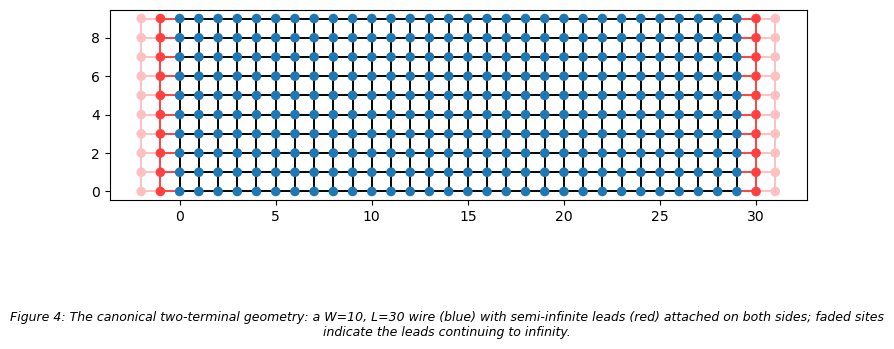

sites in scattering region: 300
leads: 2


In [4]:
# --- The canonical Kwant example: conductance of a quantum wire ---------------
import kwant
import numpy as np
from matplotlib import pyplot

a, t, W, L = 1, 1.0, 10, 30
lat = kwant.lattice.square(a, norbs=1)

def make_wire(W=10, L=30, t=1.0):
    syst = kwant.Builder()

    # Scattering region: on-site 4t, nearest-neighbour hopping -t
    syst[(lat(x, y) for x in range(L) for y in range(W))] = 4 * t
    syst[lat.neighbors()] = -t

    # A lead: one unit cell + translational symmetry pointing left, away from syst
    lead = kwant.Builder(kwant.TranslationalSymmetry((-a, 0)))
    lead[(lat(0, j) for j in range(W))] = 4 * t
    lead[lat.neighbors()] = -t

    syst.attach_lead(lead)               # becomes lead 0 (left)
    syst.attach_lead(lead.reversed())    # becomes lead 1 (right)
    return syst

syst = make_wire()
kwant.plot(syst, fig_size=(9, 4), show=False)
show_fig(r'The canonical two-terminal geometry: a W=10, L=30 wire (blue) with semi-infinite leads (red) attached on both sides; faded sites indicate the leads continuing to infinity.')

fsyst = syst.finalized()
print("sites in scattering region:", len(fsyst.sites))
print("leads:", len(fsyst.leads))

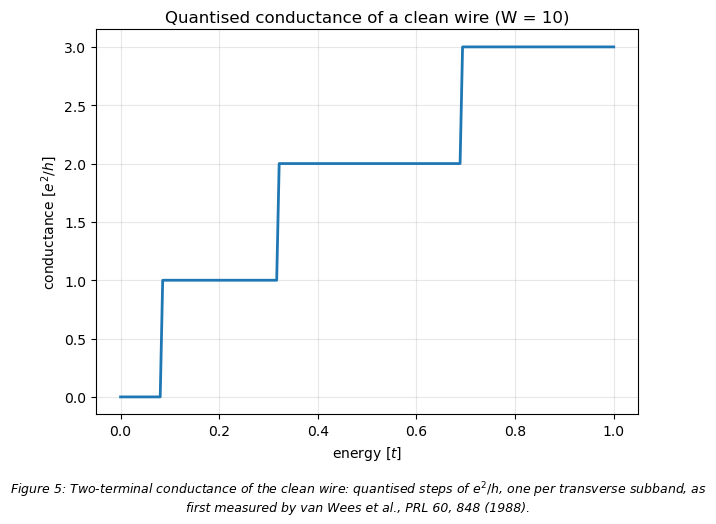

In [5]:
# --- Conductance vs energy: the quantisation staircase -----------------------
energies = np.linspace(0.0, 1.0, 200)

data = []
for energy in energies:
    smatrix = kwant.smatrix(fsyst, energy)
    data.append(smatrix.transmission(1, 0))     # from lead 0 into lead 1

pyplot.figure()
pyplot.plot(energies, data, lw=2)
pyplot.xlabel("energy $[t]$")
pyplot.ylabel(r"conductance $[e^2/h]$")
pyplot.title("Quantised conductance of a clean wire (W = 10)")
pyplot.grid(alpha=.3)
show_fig(r'Two-terminal conductance of the clean wire: quantised steps of $e^2/h$, one per transverse subband, as first measured by van Wees et al., PRL 60, 848 (1988).')

### What you should see

A **staircase**: $G$ rises in integer steps of $e^2/h$. Each step is one transverse subband
(one propagating mode) opening up as the energy is raised. For a hard-wall wire of width
$W$ the transverse modes are $\sin(n\pi y / W)$ with energies

$$E_n = 4t - 2t\cos\!\left(\frac{n\pi}{W+1}\right) - 2t\cos(k_x a),$$

so the $n$-th step occurs when the bottom of subband $n$ crosses $E$. In a *clean* wire
every open mode transmits perfectly, $T = N_{\text{open}}$ — the steps are flat and integer.
Add disorder (try it!) and they degrade.

This single plot is the "hello world" of mesoscopic physics: it is the Landauer result,
and its experimental observation in quantum point contacts is what the theory was built to
explain.

---
## 4. Theory — Scattering theory: Landauer–Büttiker and Fisher–Lee

### The Landauer picture

A mesoscopic conductor is not described by a local conductivity. It is a **scatterer**
connected to reservoirs by ballistic leads. Electrons enter from a lead in one of its
propagating modes, scatter, and leave into some mode of some lead. All transport
information is in the **scattering matrix** $S$, which relates outgoing to incoming mode
amplitudes:

$$\begin{pmatrix}b_1\\ b_2\\ \vdots\end{pmatrix}
= S \begin{pmatrix}a_1\\ a_2\\ \vdots\end{pmatrix},
\qquad
S = \begin{pmatrix} r & t' \\ t & r' \end{pmatrix}.$$

$S$ is **unitary** ($S^\dagger S = 1$) — that is current conservation, and it is the single
most useful numerical check you have.

The **Landauer formula** for a two-terminal conductor at zero temperature:

$$G = \frac{e^2}{h}\,T, \qquad T = \operatorname{Tr}\big(t^\dagger t\big) = \sum_{mn}|t_{nm}|^2.$$

(The spin degeneracy factor of 2 is *not* included — if your model is spinless and you want
to compare to experiment, put it in by hand.)

The **Büttiker generalisation** to many terminals, which is what Kwant actually implements:

$$I_i = \frac{e^2}{h}\sum_{j} \left(T_{ij}V_j - T_{ji}V_i\right),
\qquad T_{ij} = \operatorname{Tr}\big(t_{ij}^\dagger t_{ij}\big).$$

Büttiker's insight: **a voltage probe is just another lead**, and treating it as such
automatically produces the right multi-terminal relations. Sum rules
$\sum_j T_{ij} = \sum_j T_{ji} = N_i$ follow from unitarity.

### Fisher–Lee: from Green's functions to $S$

Kwant does not compute $S$ from a wave-function ansatz alone; it uses the relation between
the scattering matrix and the retarded Green's function of the system,

$$S_{ij} = -\delta_{ij} + i\,\Gamma_i^{1/2}\,G^{r}\,\Gamma_j^{1/2},
\qquad G^{r} = \left(E - H - \sum_i \Sigma_i\right)^{-1},$$

where the **self-energy** $\Sigma_i$ encodes the semi-infinite lead $i$ exactly, and
$\Gamma_i = i(\Sigma_i - \Sigma_i^\dagger)$ is the corresponding level-broadening.
This is the Fisher–Lee relation.

The crucial practical point: **the infinite leads are eliminated exactly**, not truncated.
$\Sigma_i$ is obtained from the lead's mode structure — a self-consistent surface Green's
function / generalised eigenvalue problem over one unit cell. So the numerical problem is
finite (the scattering region) even though the physical system is infinite.

### What Kwant actually solves

Rather than inverting for $G^r$ (dense, expensive), Kwant sets up a **sparse linear system**
whose solution is the scattering wave function, and solves it with a sparse LU
factorisation (MUMPS when available). This is the "wave-function method" and it is why
Kwant scales to large systems.

Two entry points, and the difference matters:

| Function | Returns | Use when |
|---|---|---|
| `kwant.smatrix(fsyst, E, params=...)` | `SMatrix` — transmission, reflection, blocks | you want conductance / $S$ |
| `kwant.wave_function(fsyst, E, params=...)` | callable → array of scattering states | you want densities, currents, maps |

Also available: `kwant.greens_function` (the full $G^r$ between leads) and
`kwant.ldos` (local density of states).

*Further reading:* R. Landauer, IBM J. Res. Dev. **1**, 223 (1957);
M. Büttiker, PRL **57**, 1761 (1986); S. Datta, *Electronic Transport in
Mesoscopic Systems* (Cambridge, 1995); C. W. J. Beenakker & H. van Houten,
Solid State Physics **44**, 1 (1991).  The algorithms behind `kwant.smatrix`
are described in the Kwant paper: C. W. Groth *et al.*, New J. Phys. **16**,
063065 (2014).


In [6]:
# --- Anatomy of the scattering matrix, and unitarity as a sanity check --------
smatrix = kwant.smatrix(fsyst, energy=0.6)

print("num propagating modes in lead 0:", smatrix.num_propagating(0))
print("num propagating modes in lead 1:", smatrix.num_propagating(1))

t10 = smatrix.submatrix(1, 0)      # transmission block  lead 0 -> lead 1
r00 = smatrix.submatrix(0, 0)      # reflection block    lead 0 -> lead 0
print("\nshape of t_10:", t10.shape)

T = smatrix.transmission(1, 0)
R = smatrix.transmission(0, 0)
N = smatrix.num_propagating(0)
print("\nT      = %.10f" % T)
print("R      = %.10f" % R)
print("T + R  = %.10f   (should equal N = %d)" % (T + R, N))

# Unitarity of the full S matrix -- the strongest correctness check available
S = smatrix.data
err = np.max(np.abs(S.conj().T @ S - np.eye(S.shape[0])))
print("\nmax |S^dag S - 1| = %.2e" % err)

num propagating modes in lead 0: 2
num propagating modes in lead 1: 2

shape of t_10: (2, 2)

T      = 2.0000000000
R      = 0.0000000000
T + R  = 2.0000000000   (should equal N = 2)

max |S^dag S - 1| = 2.48e-14


states incoming from lead 0: (2, 300)


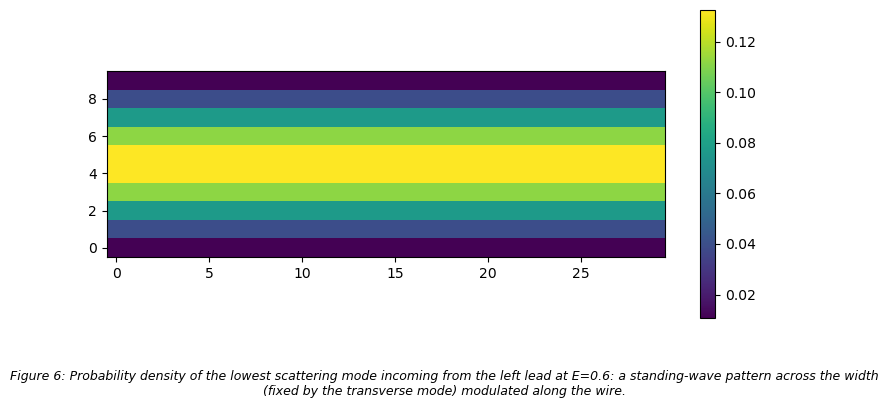

In [7]:
# --- Scattering wave functions, and where they live --------------------------
wf = kwant.wave_function(fsyst, energy=0.6)

psi_from_left = wf(0)            # shape: (n_modes, n_orbitals_in_scattering_region)
print("states incoming from lead 0:", psi_from_left.shape)

# Probability density of the lowest incoming mode, mapped onto the lattice
kwant.plotter.map(fsyst, np.abs(psi_from_left[0])**2,
                  fig_size=(9, 4), cmap='viridis', show=False)
show_fig(r'Probability density of the lowest scattering mode incoming from the left lead at E=0.6: a standing-wave pattern across the width (fixed by the transverse mode) modulated along the wire.')